# EDA

## Import Libraries

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

## Load Data

In [12]:
df = pd.read_csv("../data/raw/municipal_complaints_raw.csv")

## View Data

In [13]:
df.head()

,complaint_id,citizen_id,category,sub_category,ward,reported_date,status,people_affected,vulnerable_population,essential_service,public_safety_risk,recurrence_indicator,estimated_effort_hours,severity
0,C000001,P0869,Drainage,Drain Blockage,Peenya,2025-10-01,Closed,230.0,39.0,No,Medium,No,4.0,High
1,C000002,P0993,Sewerage,Sewage Overflow,Hennur,2025-10-01,Resolved,70.0,14.0,Yes,Critical,No,8.0,Medium
2,C000003,P1709,Street Infrastructure,Fallen Tree Branch,Dasarahalli,2025-10-01,Closed,190.0,12.0,No,Medium,No,12.0,Medium
3,C000004,P1458,Revenue Department,Trade Licence Issue,Chickpet,2025-10-01,Resolved,7.0,2.0,No,NaN,No,2.0,Low
4,C000005,P1565,Water Supply,No Water Supply,Vasanthnagar,2025-10-01,Closed,140.0,21.0,Yes,Low,No,12.0,High


Features identified for removal during preprocessing
These features are not used for ML model training:
1. essential_service
2. estimated_effort_hours

In [14]:
df.shape

(9217, 14)

In [15]:
df.columns

Index(['complaint_id', 'citizen_id', 'category', 'sub_category', 'ward',
       'reported_date', 'status', 'people_affected', 'vulnerable_population',
       'essential_service', 'public_safety_risk', 'recurrence_indicator',
       'estimated_effort_hours', 'severity'],
      dtype='str')

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9217 entries, 0 to 9216
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   complaint_id            9217 non-null   str    
 1   citizen_id              9217 non-null   str    
 2   category                9217 non-null   str    
 3   sub_category            9217 non-null   str    
 4   ward                    9217 non-null   str    
 5   reported_date           9217 non-null   str    
 6   status                  9217 non-null   str    
 7   people_affected         9056 non-null   float64
 8   vulnerable_population   8945 non-null   float64
 9   essential_service       9095 non-null   str    
 10  public_safety_risk      7360 non-null   str    
 11  recurrence_indicator    9038 non-null   str    
 12  estimated_effort_hours  8998 non-null   float64
 13  severity                9217 non-null   str    
dtypes: float64(3), str(11)
memory usage: 1.7 MB


## Summary Statistics

In [17]:
df.describe()

,people_affected,vulnerable_population,estimated_effort_hours
count,9056.000000,8945.000000,8998.000000
mean,253.240835,25.675014,6.470382
std,998.078908,75.918619,7.720929
min,0.000000,0.000000,0.500000
25%,40.000000,2.000000,2.000000
50%,95.000000,7.000000,4.000000
75%,210.000000,22.000000,8.000000
max,28800.000000,4017.000000,168.000000


In [18]:
df.describe(include="object")

,complaint_id,citizen_id,category,sub_category,ward,reported_date,status,essential_service,public_safety_risk,recurrence_indicator,severity
count,9217,9217,9217,9217,9217,9217,9217,9095,7360,9038,9217
unique,9217,2456,20,74,74,365,6,2,4,2,4
top,C000001,P0349,Solid Waste Management,Garbage Not Collected,Mathikere,2026-08-20,Closed,No,Low,No,Medium
freq,1,52,2424,1132,802,64,4038,6259,2768,4763,3641


## Missing Value Analysis

In [21]:
df.isnull().sum()

complaint_id                 0
citizen_id                   0
category                     0
sub_category                 0
ward                         0
reported_date                0
status                       0
people_affected            161
vulnerable_population      272
essential_service          122
public_safety_risk        1857
recurrence_indicator       179
estimated_effort_hours     219
severity                     0
dtype: int64

## Duplicate Rows

In [22]:
df.duplicated().sum()

np.int64(0)

## Unique Values

In [23]:
df.nunique()

complaint_id              9217
citizen_id                2456
category                    20
sub_category                74
ward                        74
reported_date              365
status                       6
people_affected            565
vulnerable_population      317
essential_service            2
public_safety_risk           4
recurrence_indicator         2
estimated_effort_hours      16
severity                     4
dtype: int64

## Catogorical Columns

In [24]:
df["category"].value_counts()

category
Solid Waste Management     2424
Electrical                 1518
Water Supply               1049
Road Maintenance           1005
Drainage                    838
Sewerage                    636
Health                      461
Public Sanitation           438
Road Infrastructure         306
Street Infrastructure       228
Others                      160
Revenue Department          136
Road Infrastructure           5
Solid Waste Management        3
Water Supply                  3
Electrical                    2
Drainage                      2
Public Sanitation             1
Road Maintenance              1
Health                        1
Name: count, dtype: int64

In [25]:
df["sub_category"].value_counts()

sub_category
Garbage Not Collected                 1132
Street Light Not Working               688
Pothole                                537
Multiple Street Lights Not Working     525
Garbage Vehicle Not Arrived            492
                                      ... 
Drain Overflow                           1
garbage not collected                    1
Damaged Street Light                     1
garbage vehicle not arrived              1
Road Surface Damage                      1
Name: count, Length: 74, dtype: int64

In [26]:
df["ward"].value_counts()

ward
Mathikere          802
Hosahalli          580
Kadugodi           477
Dasarahalli        382
Sadashivanagar     309
                  ... 
SARAKKI              1
JP NAGAR             1
Kodigehalli          1
ELECTRONIC CITY      1
KODIGEHALLI          1
Name: count, Length: 74, dtype: int64

In [28]:
df["status"].value_counts()

status
Closed         4038
Resolved       3824
In Progress     558
Assigned        363
Verified        243
Registered      191
Name: count, dtype: int64

In [29]:
df["severity"].value_counts()

severity
Medium      3641
Low         2778
High        2061
Critical     737
Name: count, dtype: int64

In [30]:
df["reported_date"].min()

'2025-10-01'

In [31]:
df["reported_date"].max()

'2026-09-30'

,people_affected,vulnerable_population,estimated_effort_hours
count,9056.000000,8945.000000,8998.000000
mean,253.240835,25.675014,6.470382
std,998.078908,75.918619,7.720929
min,0.000000,0.000000,0.500000
25%,40.000000,2.000000,2.000000
50%,95.000000,7.000000,4.000000
75%,210.000000,22.000000,8.000000
max,28800.000000,4017.000000,168.000000


## Visualization

### Severity distribution

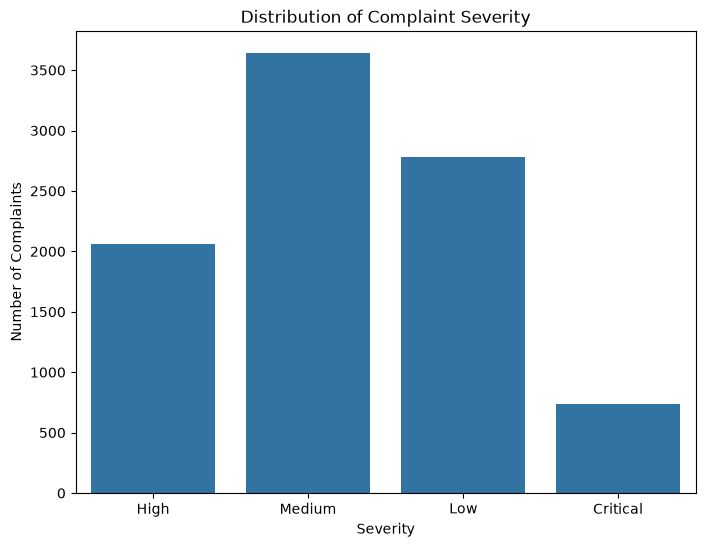

In [42]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="severity")
plt.title("Distribution of Complaint Severity")
plt.xlabel("Severity")
plt.ylabel("Number of Complaints")
plt.show()

#### Complaints by category

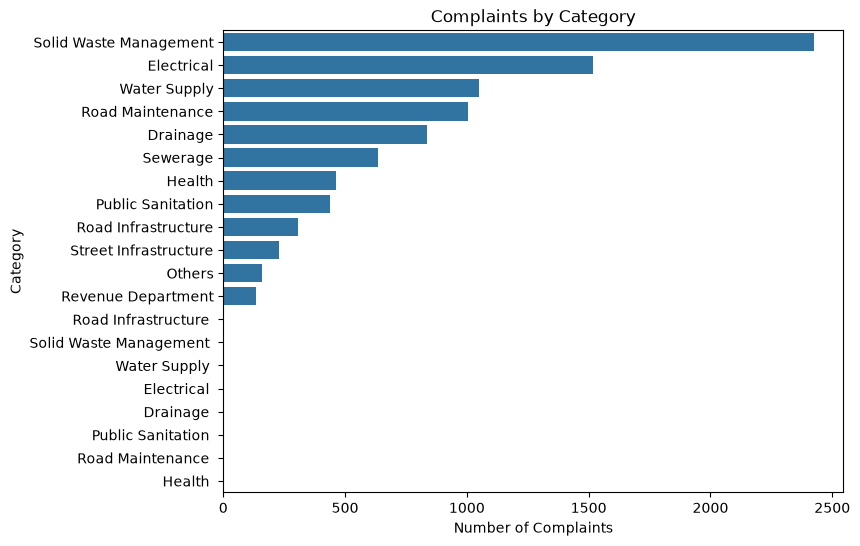

In [38]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, y="category", order=df["category"].value_counts().index)
plt.title("Complaints by Category")
plt.xlabel("Number of Complaints")
plt.ylabel("Category")
plt.show()

In [39]:
for category in df["category"].unique():
    print(repr(category))

'Drainage'
'Sewerage'
'Street Infrastructure'
'Revenue Department'
'Water Supply'
'Road Maintenance'
'Road Infrastructure'
'Health'
'Solid Waste Management'
'Public Sanitation'
'Electrical'
'Others'
'Electrical '
'Road Infrastructure '
'Solid Waste Management '
'Drainage '
'Water Supply '
'Public Sanitation '
'Road Maintenance '
'Health '


In [41]:
df["category"].str.strip().nunique()

12

#### EDA Finding — Category Inconsistency

Some category names have extra spaces, making the same category appear as different categories.

Examples:

Electrical and Electrical
Road Infrastructure and Road Infrastructure
Drainage and Drainage

This can affect visualizations, value_counts() and nunique().

Action: Remove extra spaces from categorical columns during preprocessing using .str.strip().

### Severity vs Category

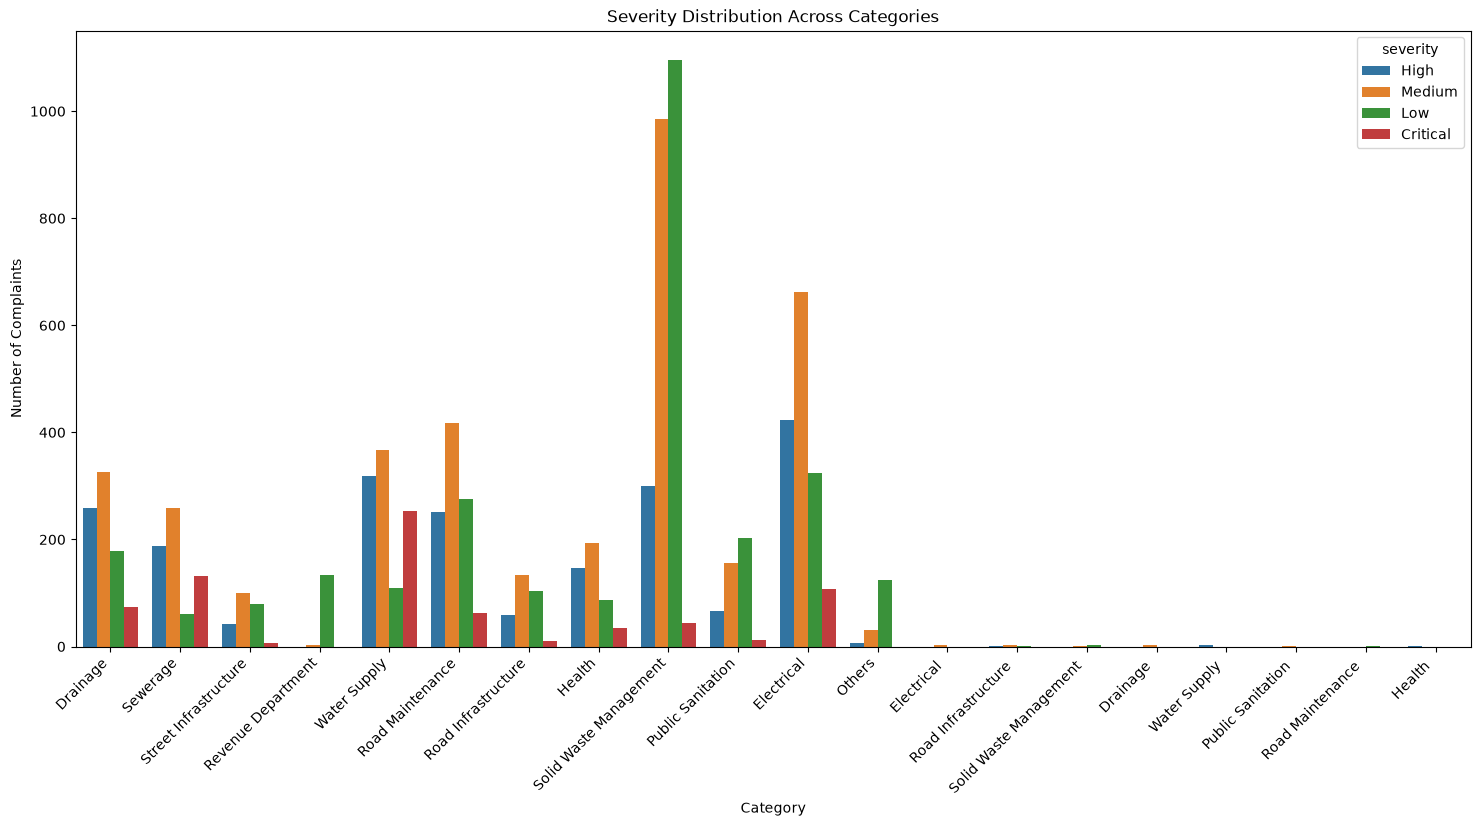

In [48]:
plt.figure(figsize=(18, 8))
sns.countplot(data=df, x="category", hue="severity")
plt.title("Severity Distribution Across Categories")
plt.xlabel("Category")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha="right")
plt.show()

### Public safety risk vs severity

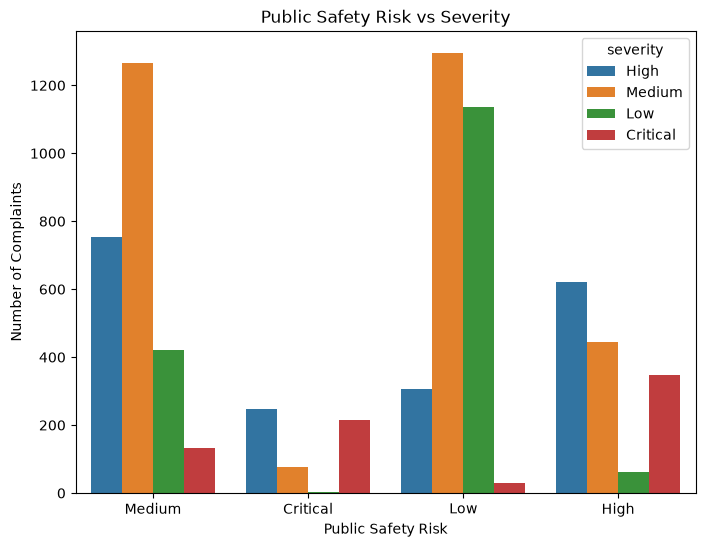

In [50]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="public_safety_risk", hue="severity")
plt.title("Public Safety Risk vs Severity")
plt.xlabel("Public Safety Risk")
plt.ylabel("Number of Complaints")
plt.show()

### Essential service vs severity

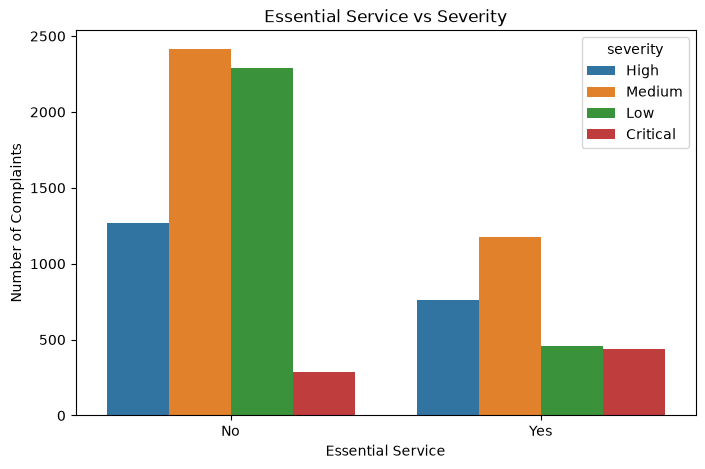

In [51]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="essential_service", hue="severity")
plt.title("Essential Service vs Severity")
plt.xlabel("Essential Service")
plt.ylabel("Number of Complaints")
plt.show()

### Recurrence vs severity

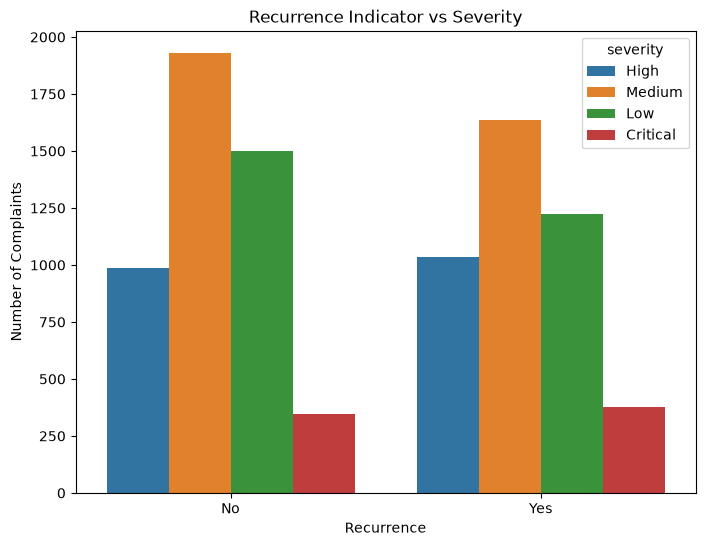

In [53]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x="recurrence_indicator", hue="severity")
plt.title("Recurrence Indicator vs Severity")
plt.xlabel("Recurrence")
plt.ylabel("Number of Complaints")
plt.show()

### People affected vs severity

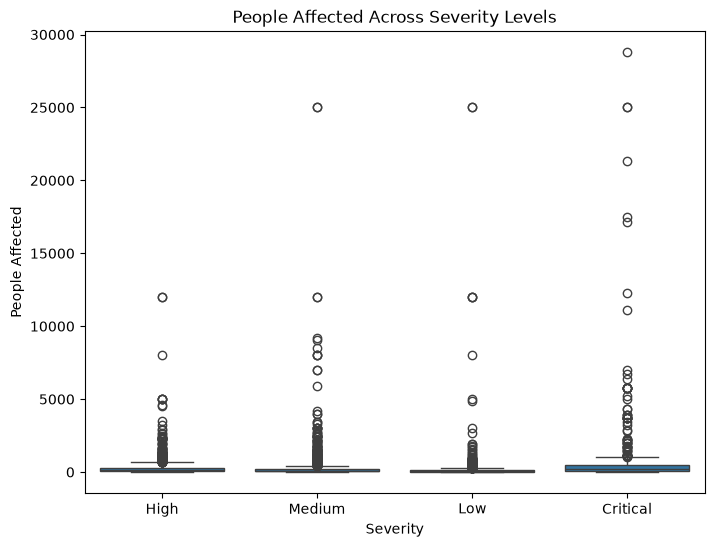

In [56]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="severity", y="people_affected")
plt.title("People Affected Across Severity Levels")
plt.xlabel("Severity")
plt.ylabel("People Affected")
plt.show()

### Vulnerable population vs severity

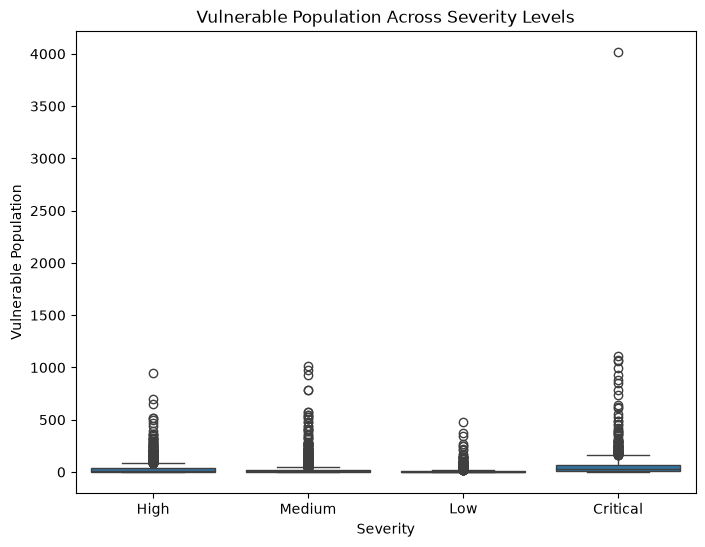

In [57]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="severity", y="vulnerable_population")
plt.title("Vulnerable Population Across Severity Levels")
plt.xlabel("Severity")
plt.ylabel("Vulnerable Population")
plt.show()

### Numerical correlation

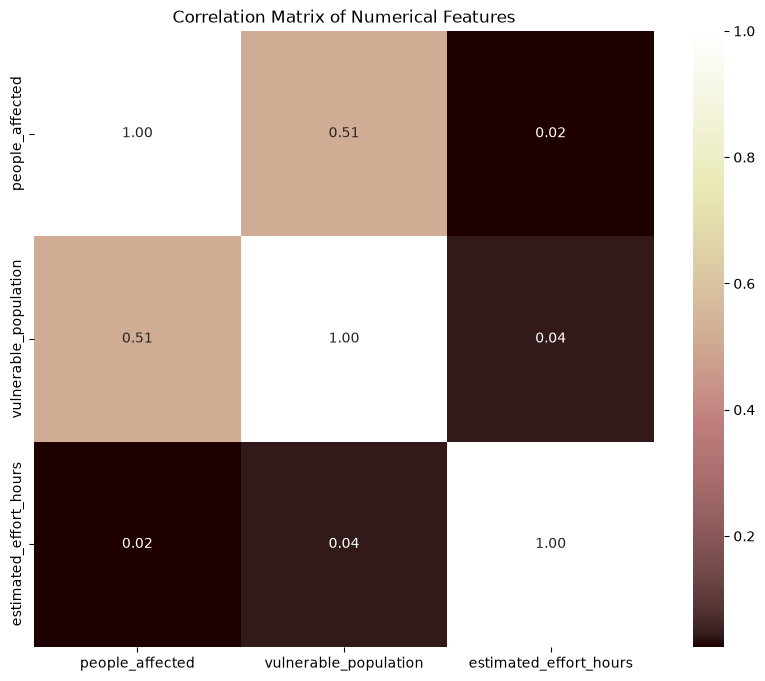

In [72]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap="pink", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()